#### We're attempting to create a plot that shows how lithium relates to calcium as a function of the total age of a system. I don't want this notebook to recompute either quantity, but rather to pull them from the CSV that I'll put the values into prior to coming here

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
start = time.time()

import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
import bensby_plotting as bp
print(os.getcwd())

all_avg
/Users/BenKaiser/Desktop/radial_velocity_calculations


In [2]:
target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/'
os.chdir(target_dir)

In [3]:
wd_abund_file='temp_wd_abundances.csv'
lodders_abund_file='Lodders2009_solarsystem_abundances.csv'

In [4]:
wd_abund_table=Table.read(wd_abund_file)
wd_abund_table.add_index('name')

In [5]:
lodders_table=Table.read(lodders_abund_file)
lodders_table.add_index('element')
solar_lica=lodders_table.loc['Li']['A_el']-lodders_table.loc['Ca']['A_el']

In [6]:

def plot_lica_age(row,sol_norm=False,lica_string='dp_chond_li/ca'):
    
    age_errs= [[row['age_minus']],[row['age_plus']]]
    #age_errs= row['age_plus'],row['age_minus']
    #age_errs=[row['age_minus'],row['age_plus']]
    lica_err= row[lica_string+'_err']
    #print('age_errs',age_errs.shape)
    #plt.errorbar(row['age'],row[lica_string],xerr=row['age_minus'],label=row['name'],marker='o')
    if sol_norm:
        plt.errorbar(float(row['age']),row[lica_string]-solar_lica,xerr=age_errs,label=row['name'],yerr=lica_err,marker='o')
        plt.ylabel('[Li/Ca]')
    else:
        plt.errorbar(float(row['age']),row[lica_string],xerr=age_errs,label=row['name'],yerr=lica_err,marker='o')
        plt.ylabel(r'$\log_{10}$(Li/Ca)')
    return

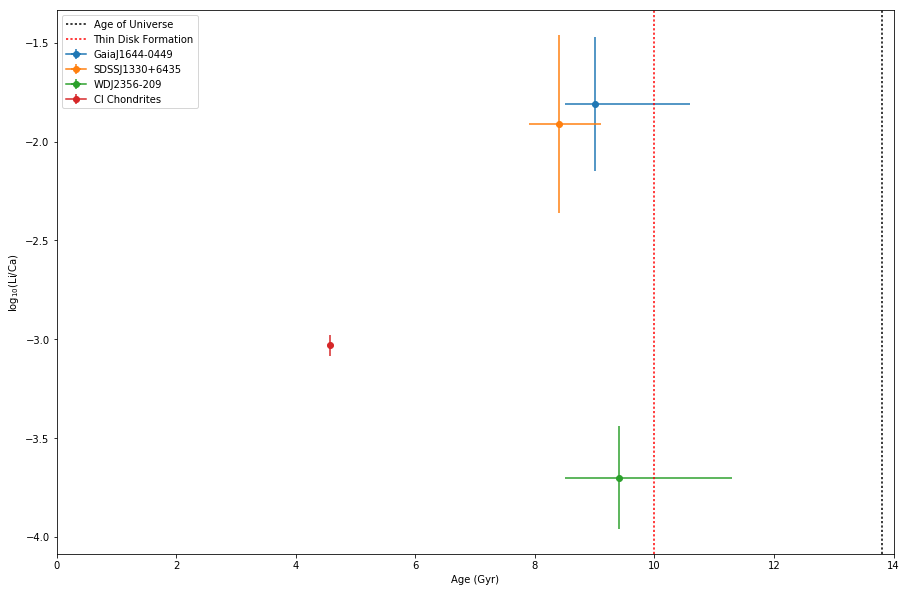

In [7]:
plt.figure(figsize=(15,10))
count=0
for row in wd_abund_table:
    if count > 2:
        break
    plot_lica_age(row)
    count+=1
plt.errorbar(4.57,solar_lica,yerr=np.sqrt(lodders_table.loc['Li']['A_el_err']**2+lodders_table.loc['Ca']['A_el_err']**2),label="CI Chondrites",marker='o')
plt.xlim(0,14)
plt.axvline(x=13.8, linestyle=':', label='Age of Universe', color='k')
plt.axvline(x=10, linestyle=':', label='Thin Disk Formation', color='r')
plt.legend()
plt.xlabel('Age (Gyr)')
plt.show()

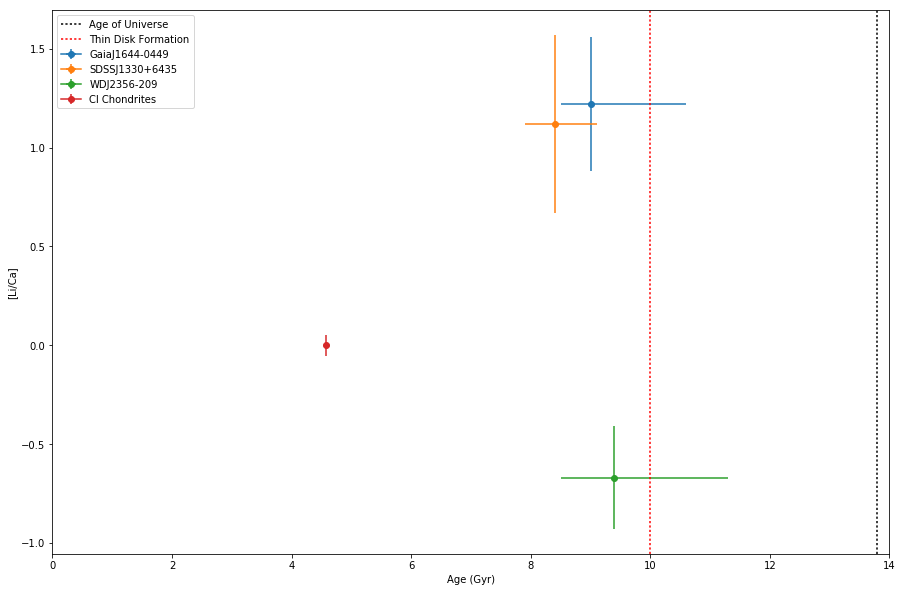

In [8]:
plt.figure(figsize=(15,10))
count=0
for row in wd_abund_table:
    if count > 2:
        break
    plot_lica_age(row,sol_norm=True)
    count+=1
plt.errorbar(4.57,0,yerr=np.sqrt(lodders_table.loc['Li']['A_el_err']**2+lodders_table.loc['Ca']['A_el_err']**2),label="CI Chondrites",marker='o')
plt.xlim(0,14)
plt.axvline(x=13.8, linestyle=':', label='Age of Universe', color='k')
plt.axvline(x=10, linestyle=':', label='Thin Disk Formation', color='r')
plt.legend()
plt.xlabel('Age (Gyr)')
plt.show()

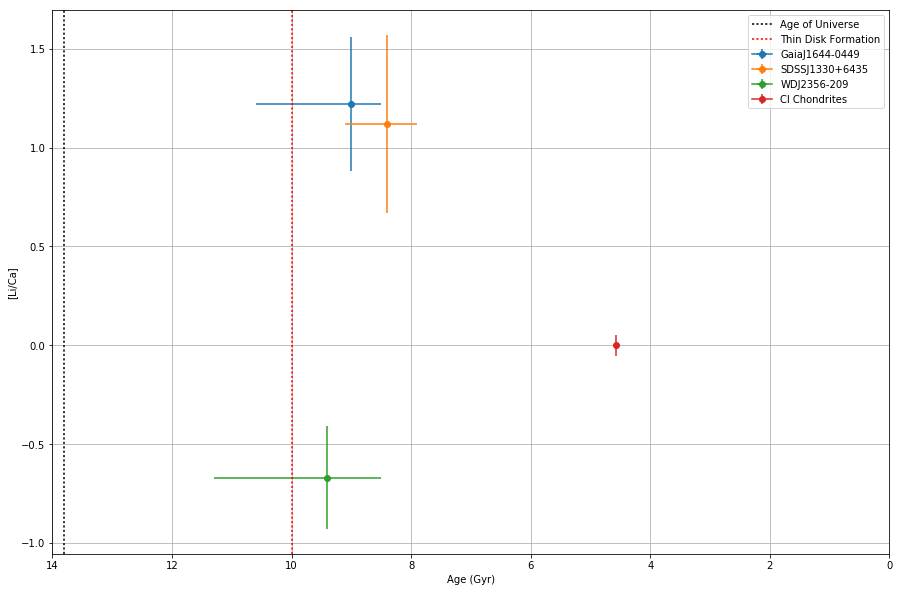

In [9]:
plt.figure(figsize=(15,10))
count=0
for row in wd_abund_table:
    if count > 2:
        break
    plot_lica_age(row,sol_norm=True)
    count+=1
plt.errorbar(4.57,0,yerr=np.sqrt(lodders_table.loc['Li']['A_el_err']**2+lodders_table.loc['Ca']['A_el_err']**2),label="CI Chondrites",marker='o')
plt.xlim(14,0)
plt.axvline(x=13.8, linestyle=':', label='Age of Universe', color='k')
plt.axvline(x=10, linestyle=':', label='Thin Disk Formation', color='r')
plt.legend()
plt.xlabel('Age (Gyr)')
plt.grid(True)
plt.show()

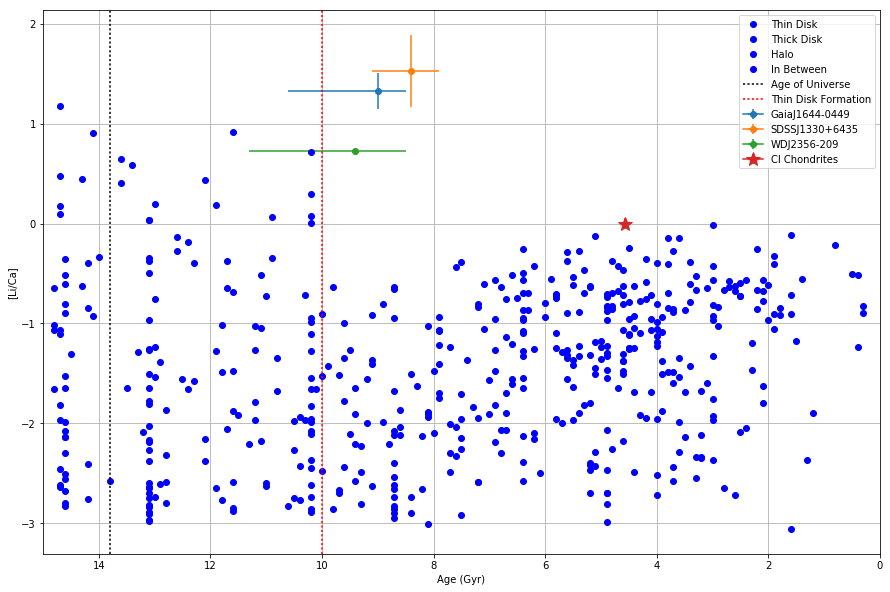

In [10]:
plt.figure(figsize=(15,10))
count=0
bp.plot_lica_age_pop()
for row in wd_abund_table:
    if count > 2:
        break
    plot_lica_age(row,sol_norm=True,lica_string='li/ca')
    count+=1
plt.errorbar(4.57,0,yerr=np.sqrt(lodders_table.loc['Li']['A_el_err']**2+lodders_table.loc['Ca']['A_el_err']**2),label="CI Chondrites",marker='*',markersize=14)
#plt.xlim(14,0)
plt.xlim(15,0)


plt.axvline(x=13.8, linestyle=':', label='Age of Universe', color='k')
plt.axvline(x=10, linestyle=':', label='Thin Disk Formation', color='r')
plt.legend()
plt.xlabel('Age (Gyr)')
plt.grid(True)
plt.show()

# 2020-03-05 Figured out I had some wrong log(Li/Ca) values kicking around in my table...

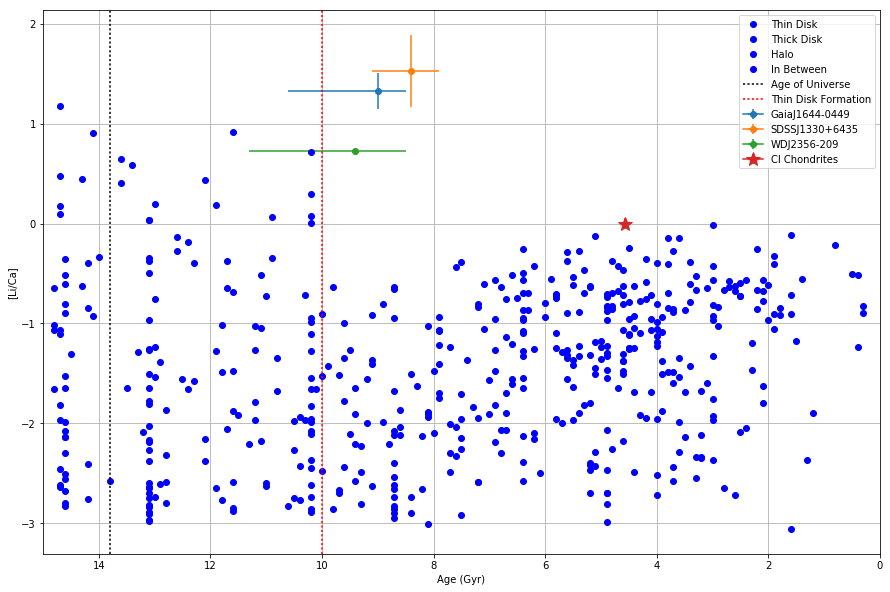

In [11]:
plt.figure(figsize=(15,10))
count=0
bp.plot_lica_age_pop()
for row in wd_abund_table:
    if count > 2:
        break
    plot_lica_age(row,sol_norm=True,lica_string='li/ca')
    count+=1
plt.errorbar(4.57,0,yerr=np.sqrt(lodders_table.loc['Li']['A_el_err']**2+lodders_table.loc['Ca']['A_el_err']**2),label="CI Chondrites",marker='*',markersize=14)
#plt.xlim(14,0)
plt.xlim(15,0)


plt.axvline(x=13.8, linestyle=':', label='Age of Universe', color='k')
plt.axvline(x=10, linestyle=':', label='Thin Disk Formation', color='r')
plt.legend()
plt.xlabel('Age (Gyr)')
plt.grid(True)
plt.show()

# 2020-04-19 Implementing Chris's changes

In [12]:
color_dict={
    'GaiaJ1644-0449':'r',
    'SDSSJ1330+6435':'darkviolet',
    'WDJ2356-209':'g'
}
step_dict={
    'GaiaJ1644-0449':10,
    'SDSSJ1330+6435':0.1,
    'WDJ2356-209':10
}

wd_marker='*'
met_marker='D'
met_color='#1ca1f2'
ci_size=14
ci_leg_size=10
wd_size=14
dp_alpha=1
arr_naca=[-0.4,-0.1]

star_marker='o'
pop_colors=['darkorange','brown','navy','grey'] #thin disk, thick disk, halo, in-between for Bensby plots



In [13]:

def plot_lica_age(row,sol_norm=True,lica_string='li/ca', color=None):
    
    age_errs= [[row['age_minus']],[row['age_plus']]]
    #age_errs= row['age_plus'],row['age_minus']
    #age_errs=[row['age_minus'],row['age_plus']]
    lica_err= row[lica_string+'_err']
    #print('age_errs',age_errs.shape)
    #plt.errorbar(row['age'],row[lica_string],xerr=row['age_minus'],label=row['name'],marker='o')
    if row['name']=='WDJ2356-209':
        if sol_norm:
            plt.errorbar(float(row['age']),row[lica_string]-solar_lica,marker=wd_marker, label=row['name'],color=color_dict[row['name']],markersize=wd_size, linestyle='None')
            plt.errorbar(float(row['age']),row[lica_string]-solar_lica,xerr=age_errs,yerr=0.3,marker=wd_marker, uplims=True,color=color_dict[row['name']],markersize=wd_size, linestyle='None')
            plt.ylabel('[Li/Ca]')
    else:
        if sol_norm:
            plt.errorbar(float(row['age']),row[lica_string]-solar_lica,xerr=age_errs,label=row['name'],yerr=lica_err,marker=wd_marker, color=color_dict[row['name']],markersize=wd_size, linestyle='None')
            plt.ylabel('[Li/Ca]')
        else:
            plt.errorbar(float(row['age']),row[lica_string],xerr=age_errs,label=row['name'],yerr=lica_err,marker='o')
            plt.ylabel(r'$\log_{10}$(Li/Ca)')
    return

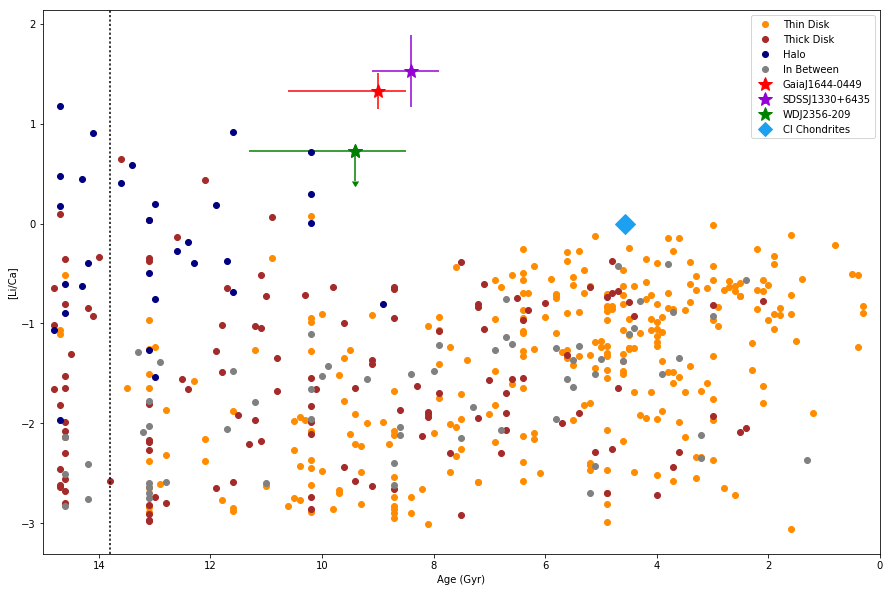

In [14]:
plt.figure(figsize=(15,10))
count=0
bp.plot_lica_age_pop(colors=pop_colors)
for row in wd_abund_table:
    if count > 2:
        break
    plot_lica_age(row,sol_norm=True,lica_string='li/ca')
    #if row['name']=='WDJ2356-209':
        
    count+=1
plt.errorbar(4.57,0,yerr=np.sqrt(lodders_table.loc['Li']['A_el_err']**2+lodders_table.loc['Ca']['A_el_err']**2),label="CI Chondrites",marker=met_marker, color=met_color, linestyle='None', markersize=ci_leg_size)
plt.errorbar(4.57,0,yerr=np.sqrt(lodders_table.loc['Li']['A_el_err']**2+lodders_table.loc['Ca']['A_el_err']**2),marker=met_marker,markersize=ci_size, color=met_color)
#plt.xlim(14,0)
plt.xlim(15,0)


plt.axvline(x=13.8, linestyle=':', color='k')
plt.legend()
#plt.grid(True)
plt.xlabel('Age (Gyr)')
plt.show()

## 2020-05-20 Simon asked to have representative error bars added to the Bensby sample, and  Chris and I agree so I'm going to tackle that

Nearly all of this effort will take place in the external python script though most likely as 

B_ALi
-----
 0.03
  0.1
 0.06
 0.06
 0.05
 0.06
 0.05
   --
 0.04
 0.05
  ...
 0.06
 0.04
   --
 0.04
 0.06
   --
 0.04
 0.09
   --
   --
 0.06
Length = 714 rows
<class 'astropy.table.column.MaskedColumn'>
star_age.shape (714,)
in_range (array([  5,  11,  13,  14,  34,  36,  39,  47,  64,  74,  83, 109, 112,
       134, 137, 151, 158, 163, 185, 186, 245, 273, 274, 277, 283, 295,
       318, 331, 335, 340, 368, 420, 438, 442, 469, 472, 478, 488, 495,
       496, 520, 590, 593, 596, 600, 606, 613, 621, 629, 636, 638, 641,
       643, 649, 664, 687, 689]),)
(714,)
max_index 368
max_lica -2.72
max age 4.0
med_age_error [ 1.9  1. ]
med_lica_error [ 0.09165151  0.09219385]
(2,)
()
brown


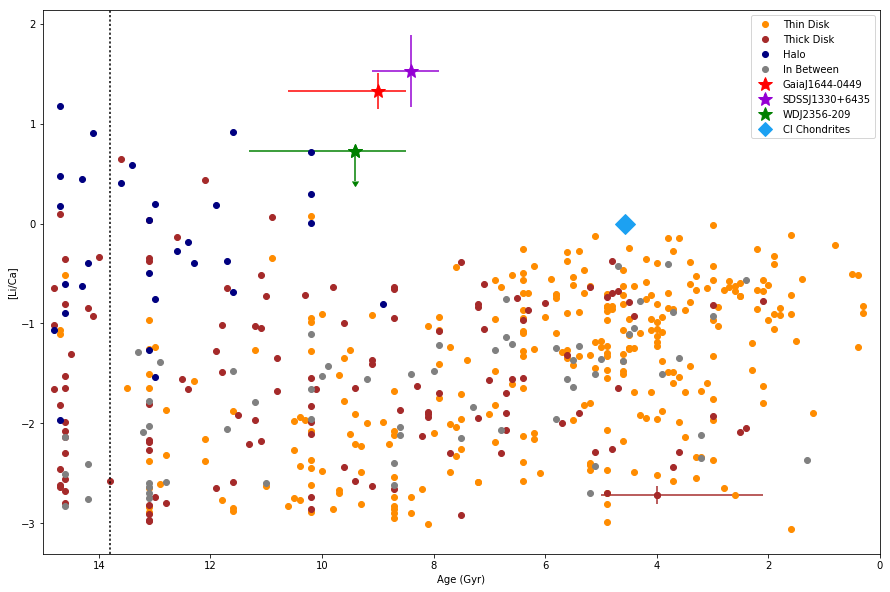

In [15]:
plt.figure(figsize=(15,10))
count=0
bp.plot_lica_age_pop(colors=pop_colors, rep_errors=True)
for row in wd_abund_table:
    if count > 2:
        break
    plot_lica_age(row,sol_norm=True,lica_string='li/ca')
    #if row['name']=='WDJ2356-209':
        
    count+=1
plt.errorbar(4.57,0,yerr=np.sqrt(lodders_table.loc['Li']['A_el_err']**2+lodders_table.loc['Ca']['A_el_err']**2),label="CI Chondrites",marker=met_marker, color=met_color, linestyle='None', markersize=ci_leg_size)
plt.errorbar(4.57,0,yerr=np.sqrt(lodders_table.loc['Li']['A_el_err']**2+lodders_table.loc['Ca']['A_el_err']**2),marker=met_marker,markersize=ci_size, color=met_color)
#plt.xlim(14,0)
plt.xlim(15,0)


plt.axvline(x=13.8, linestyle=':', color='k')
plt.legend()
#plt.grid(True)
plt.xlabel('Age (Gyr)')
plt.show()